## Dress Sales Data Analysis

### Step 2 :Perform EDA and visualization

#### Objective:
Conduct comprehensive exploratory analysis to uncover patterns and trends related to customer.

#### Analysis Approach:

###### Univariate Analysis: Understanding individual variable distributions

###### Bivariate analysis: compares price distribution across sales classes.

###### Correlation analysis: Highlights relationships between numerical variables (e.g., price and ratings).

###### Multivariate analysis: This will help you uncover relationships between multiple variables simultaneously, beyond just univariate and bivariate views.

#### 1. Import Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

#### 2. Load Dataset

In [3]:
df = pd.read_excel(r"C:\Users\987mu\OneDrive\Documents\Dress sales data.xlsx")

###### Clean column names (strip spaces, lowercase)

In [11]:
df.columns = df.columns.str.strip().str.lower()

###### Importing Numpy to replace placeholders like '?' with NaN

In [15]:
import numpy as np

In [16]:
df.replace("?", np.nan, inplace=True)


###### Convert numeric columns to proper dtype

In [17]:
numeric_cols = ["column3", "column4"] # adjust based on your dataset (e.g., Rating, Price) 
for col in numeric_cols: 
    df[col] = pd.to_numeric(df[col], errors="coerce")

###### Check for missing values

In [18]:
print(df.isnull().sum())

column1       2
column2       7
column3      17
column4     517
column5       9
column6      10
column7       9
column8      96
column9     138
column10    276
column11    246
column12    119
column13     10
column14    511
column15    512
column16    512
column17    513
column18    514
column19    514
column20    514
column21    514
column22    514
column23    515
column24    516
dtype: int64


In [19]:
df_clean = df.dropna(subset=numeric_cols)

###### Verify cleaned data types

In [20]:
print(df_clean.dtypes)

column1      object
column2      object
column3     float64
column4     float64
column5      object
column6      object
column7      object
column8      object
column9      object
column10     object
column11     object
column12     object
column13     object
column14     object
column15     object
column16     object
column17     object
column18     object
column19     object
column20     object
column21     object
column22     object
column23     object
column24     object
dtype: object


In [22]:
df.rename(columns={ "Column1": "Style", "Column2": "Price", "Column3": "Rating", "Column4": "Size", "Column5": "Season", "Column6": "NeckLine", "Column7": "SleeveLength", "Column8": "WaistLine", "Column9": "Material", "Column10": "FabricType", "Column11": "Decoration", "Column12": "PatternType", "Column13": "Class" }, inplace=True)
df.head()

,column1,column2,column3,column4,column5,column6,column7,column8,column9,column10,...,column15,column16,column17,column18,column19,column20,column21,column22,column23,column24
0,@relation R_data_frame,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,@attribute V2 {bohemian,Brief,NaN,NaN,fashion,Flare,Novelty,OL,party,sexy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,@attribute V3 {Average,high,NaN,NaN,Low,Medium,very-high},NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,@attribute V4 numeric,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 3. Exploratory Data Analysis (EDA)

##### Univariate Analysis Visuals

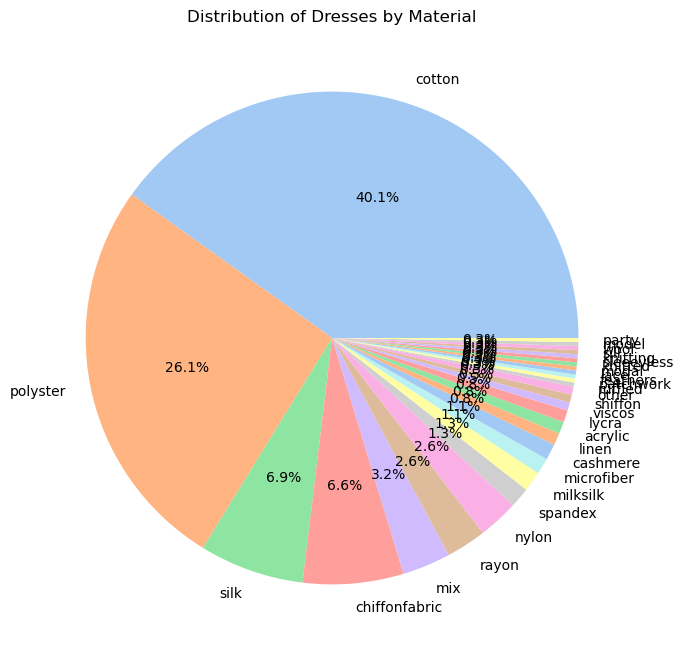

In [98]:
season_counts = df['column9'].value_counts() 
plt.figure(figsize=(12,8)) 
plt.pie(season_counts, labels=season_counts.index, autopct='%1.1f%%', colors=sns.color_palette("pastel")) 
plt.title("Distribution of Dresses by Material") 
plt.show()

###### Observation: Retailers should prioritize cotton and polyester dresses in inventory planning, as they represent mainstream demand.

##### Histogram:

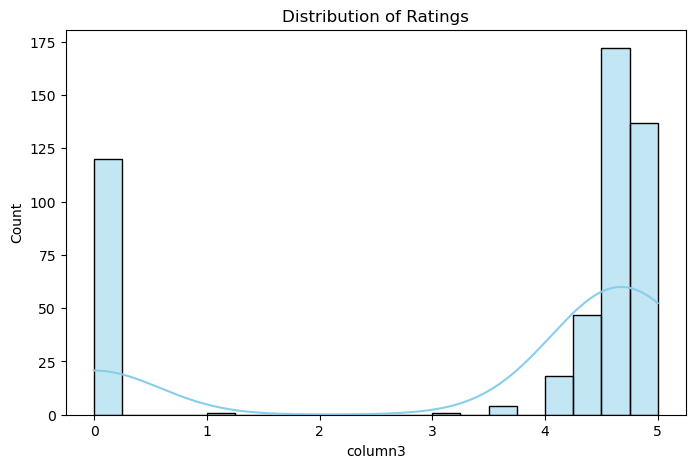

In [67]:
plt.figure(figsize=(8,5)) 
sns.histplot(df['column3'], bins=20, kde=True, color="skyblue") 
plt.title("Distribution of Ratings") 
plt.show()

###### Observation: Histogram shows the ratings to understand distribution of dress sales.A large portion of dresses either have no rating.Another large portion has high ratings, suggesting customers who did rate were generally very positive.

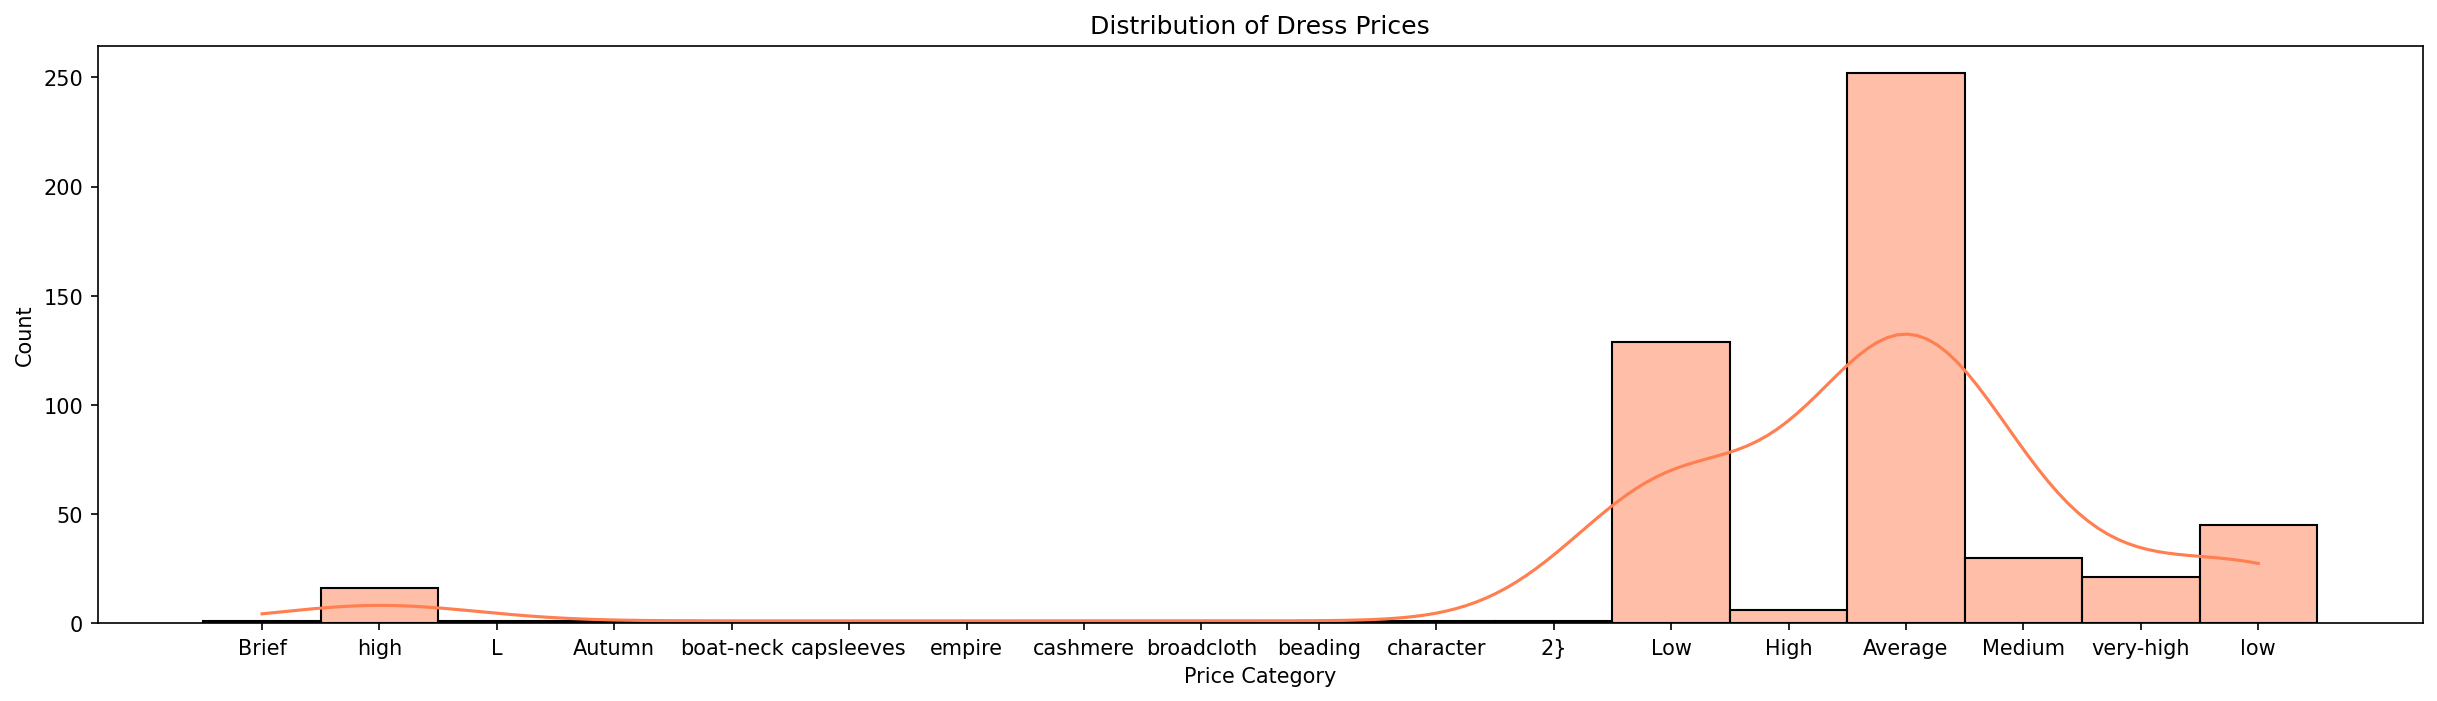

In [120]:
plt.figure(figsize=(20,5), dpi=150)
sns.histplot(df['column2'], bins=15, kde=True, color="coral")
plt.title("Distribution of Dress Prices")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.show()

###### Boxplot: Ratings
It gives a compact summary of how ratings are distributed in the dataset.

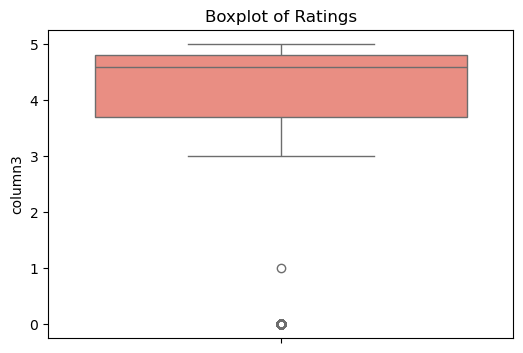

In [24]:
plt.figure(figsize=(6,4)) 
sns.boxplot(y=df['column3'], color="salmon") 
plt.title("Boxplot of Ratings") 
plt.show()

###### Observation:The central line in the box shows the median rating. In this case, it’s close to the maximum (around 4.5–5), meaning most valid ratings are high.

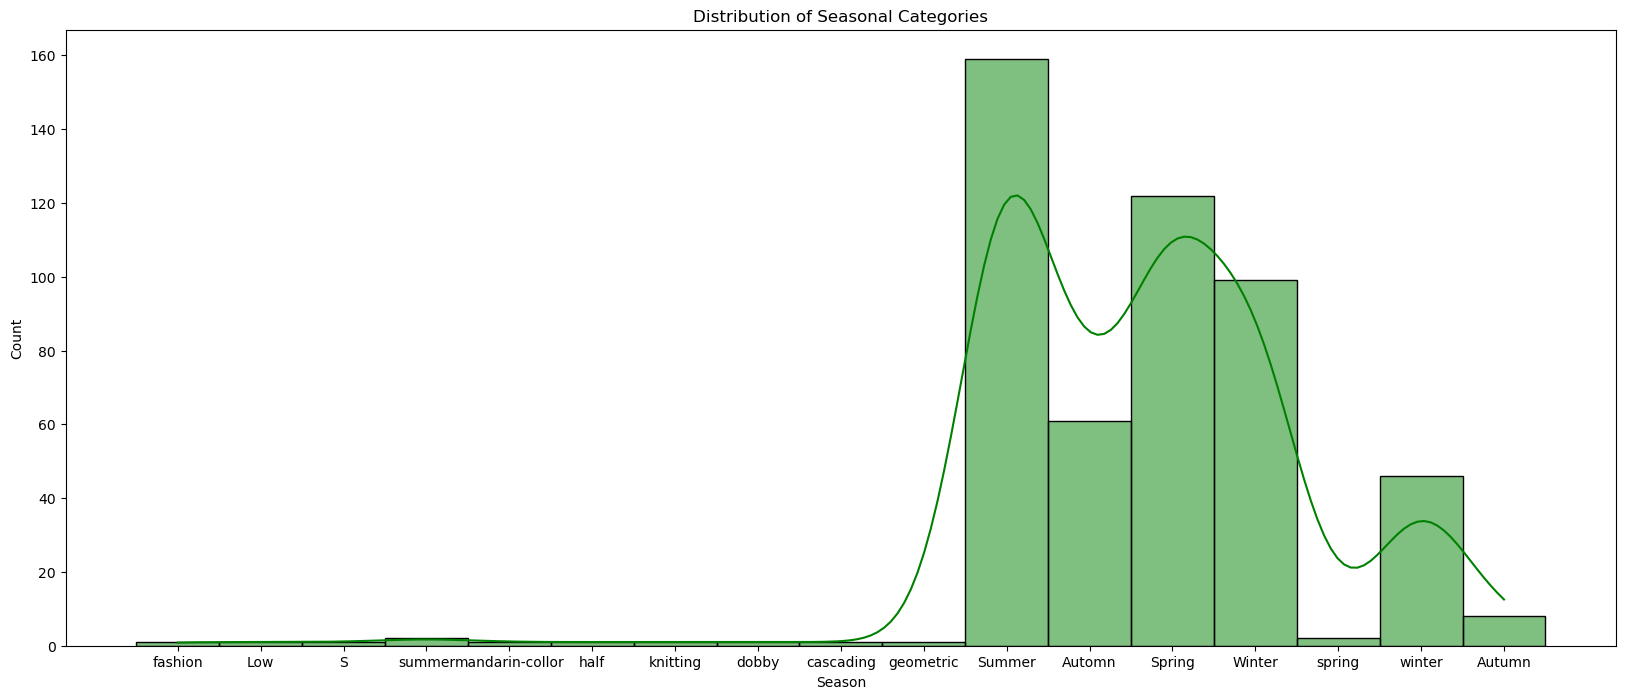

In [51]:
plt.figure(figsize=(20,8)) 
sns.histplot(df['column5'], bins=20, kde=True, color="green") 
plt.title("Distribution of Seasonal Categories") 
plt.xlabel('Season')
plt.show()

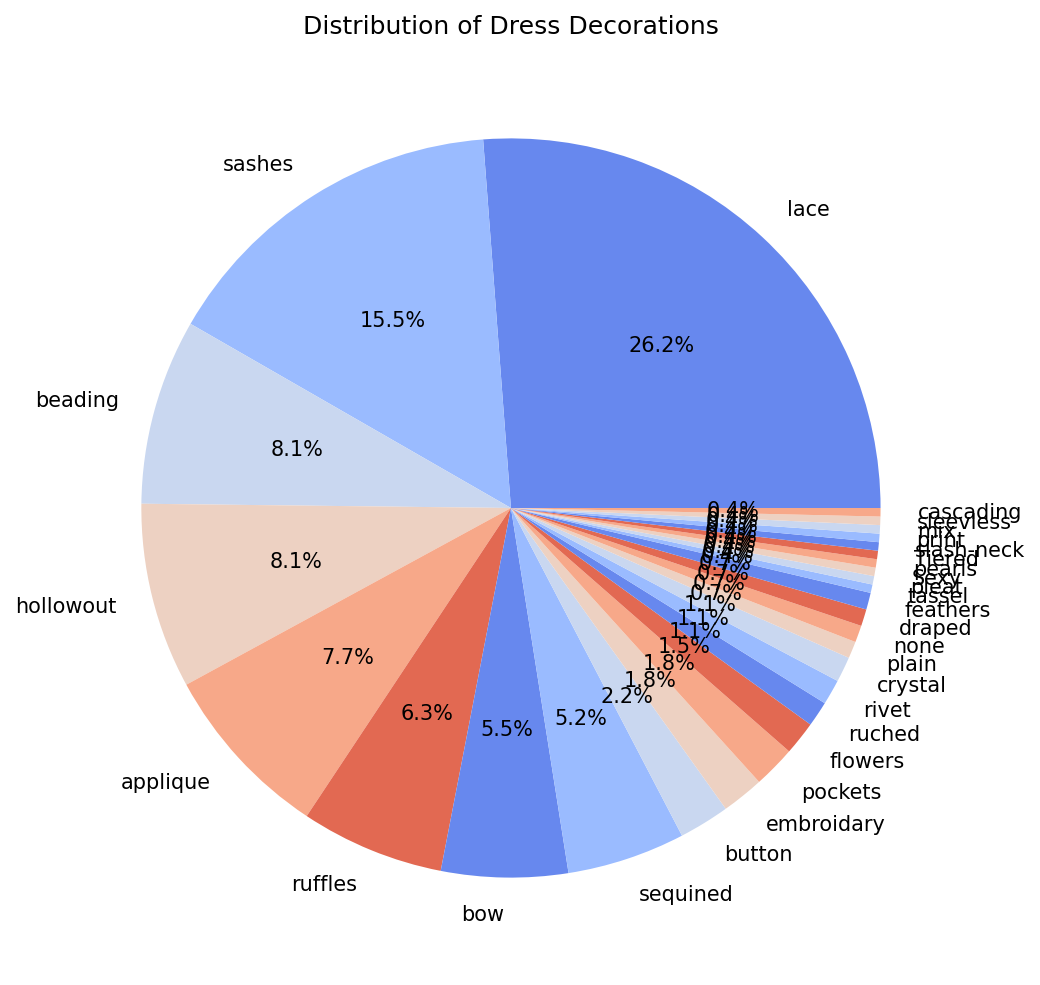

In [127]:
decoration_counts = df['column11'].value_counts() 
plt.figure(figsize=(8,8), dpi=150) 
plt.pie(decoration_counts, labels=decoration_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette("coolwarm"), textprops={'fontsize':10}) 
plt.title("Distribution of Dress Decorations") 
plt.show()

###### Observation:This suggests lace is a highly popular embellishment, often associated with elegance and premium appeal.

##### Bivariate Analysis
It shows how different dress styles (Column2) are distributed across price categories (Column3).

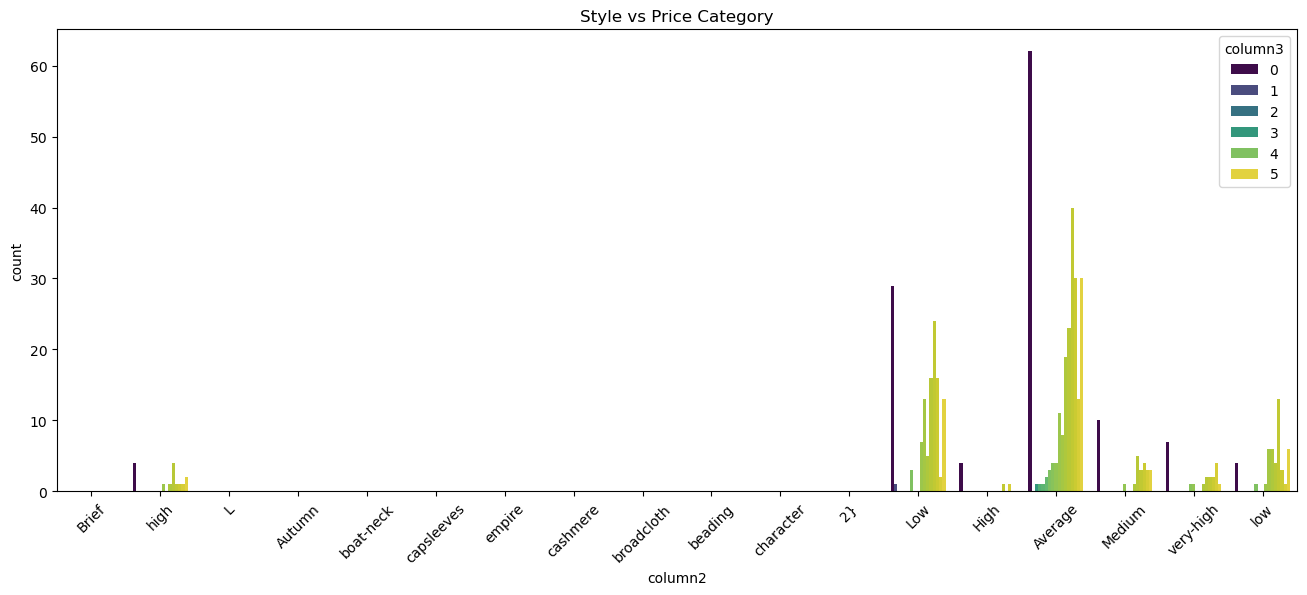

In [74]:
plt.figure(figsize=(16,6)) 
sns.countplot(x="column2", hue="column3", data=df, palette="viridis") 
plt.title("Style vs Price Category") 
plt.xticks(rotation=45) 
plt.show()

###### Observation:The dataset is imbalanced toward Casual dresses, which dominate sales records.Price categories are mostly Low and Average.

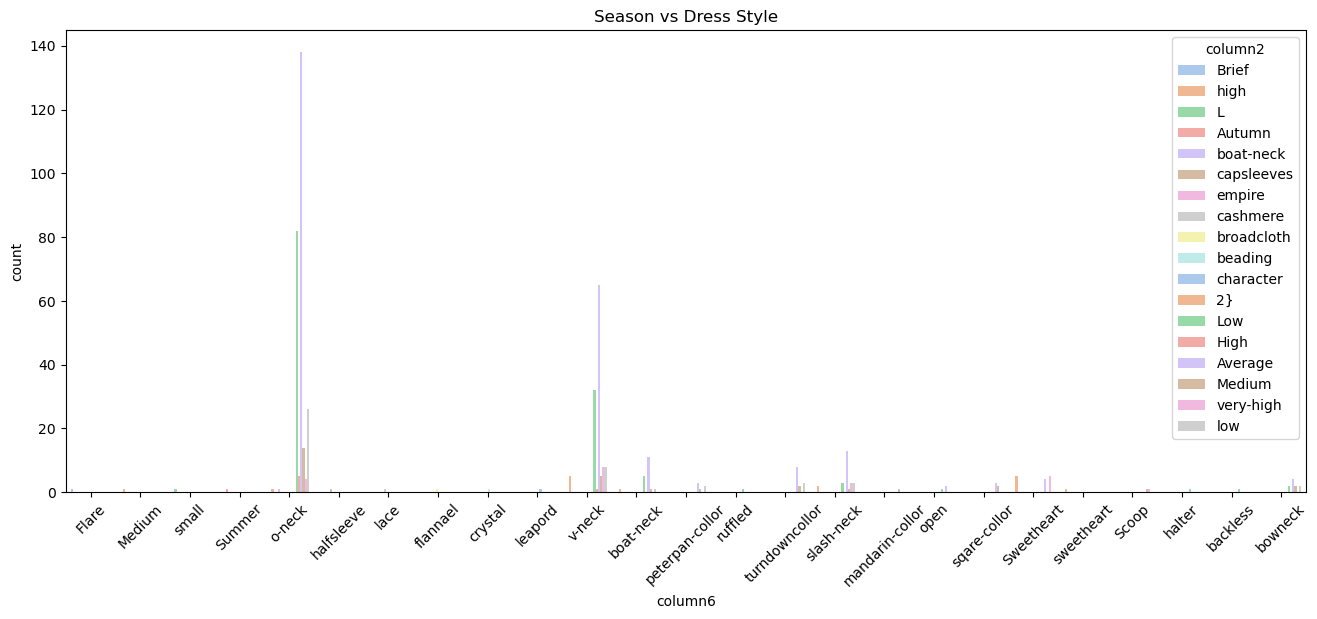

In [57]:
plt.figure(figsize=(16,6)) 
sns.countplot(x="column6", hue="column2", data=df, palette="pastel") 
plt.title("Season vs Dress Style") 
plt.xticks(rotation=45) 
plt.show()

###### Observation:Casual is the most common style across all seasons, while Party and Sexy dominate in festive/winter contexts.This suggests that seasonality influences style trends, with lighter, casual dresses in Summer and more elaborate styles in Winter.

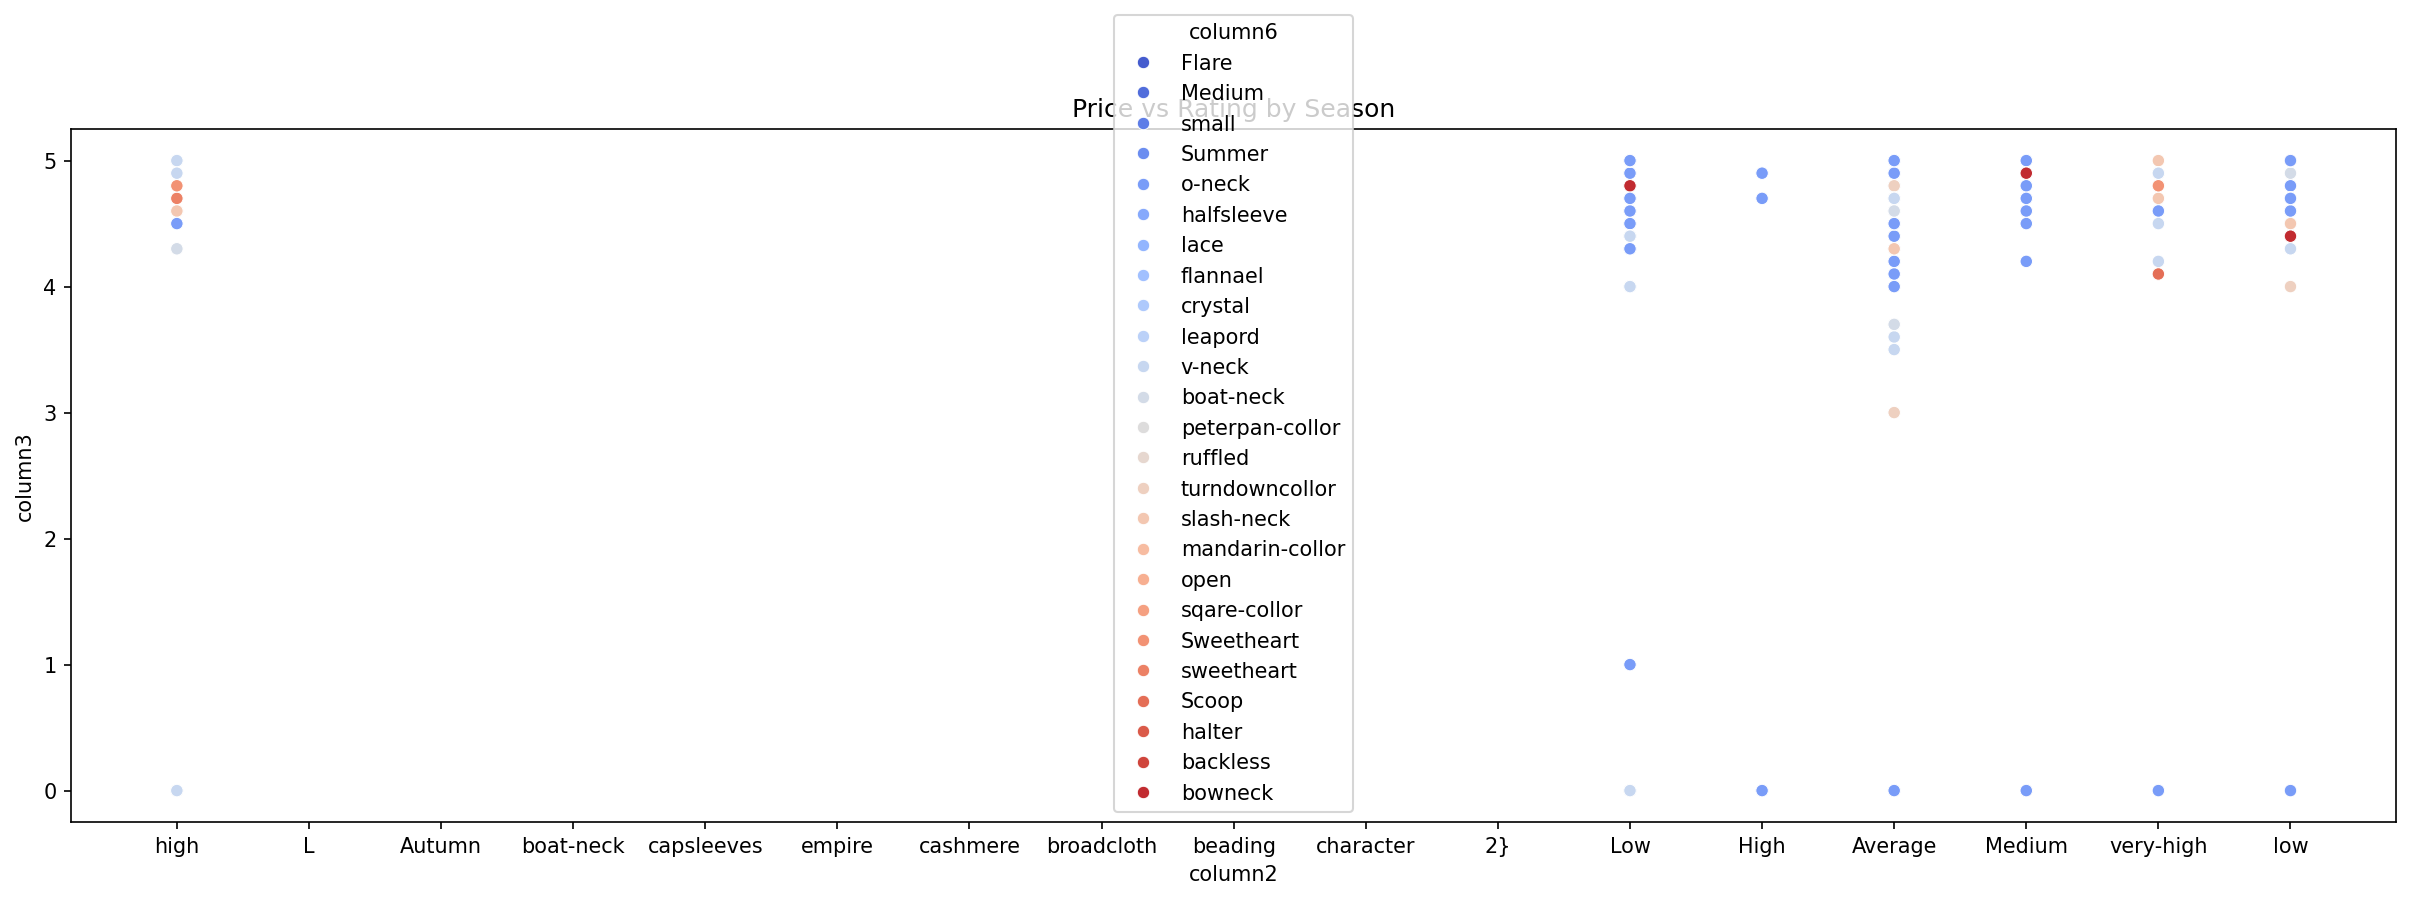

In [97]:
plt.figure(figsize=(20,6), dpi=150) 
sns.scatterplot(x="column2", y="column3", data=df, hue="column6", palette="coolwarm") 
plt.title("Price vs Rating by Season") 
plt.show()

###### Observation: Price categories are spread across styles, but ratings cluster mostly between 3–5, showing that most dresses receive favorable ratings regardless of price.

##### Multivariate Analysis
 Material vs Decoration Distribution bar chart shows how different materials are associated with various decorations.

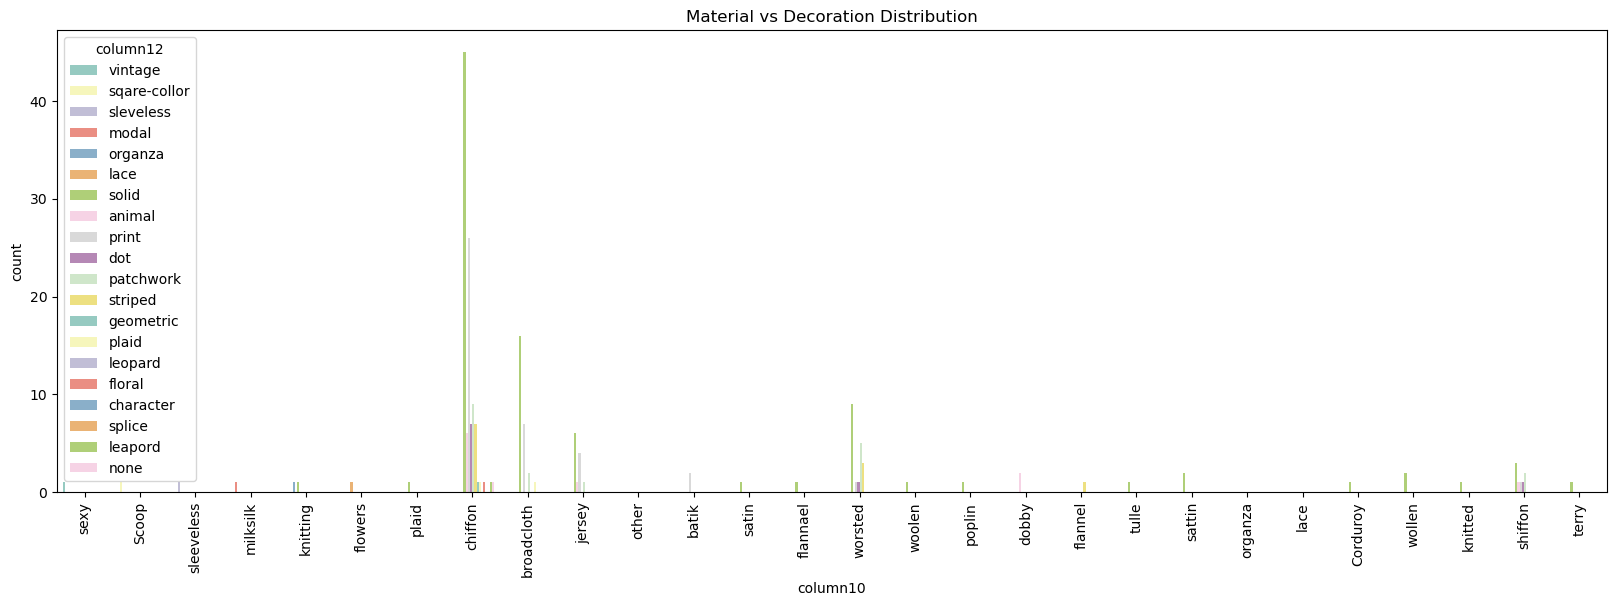

In [65]:
plt.figure(figsize=(20,6))
sns.countplot(x="column10", hue="column12", data=df, palette="Set3") 
plt.title("Material vs Decoration Distribution") 
plt.xticks(rotation=90) 
plt.show()

###### Observation:The dataset suggests cotton, polyester, and chiffon are the core fabrics, supporting a wide variety of decorative styles.

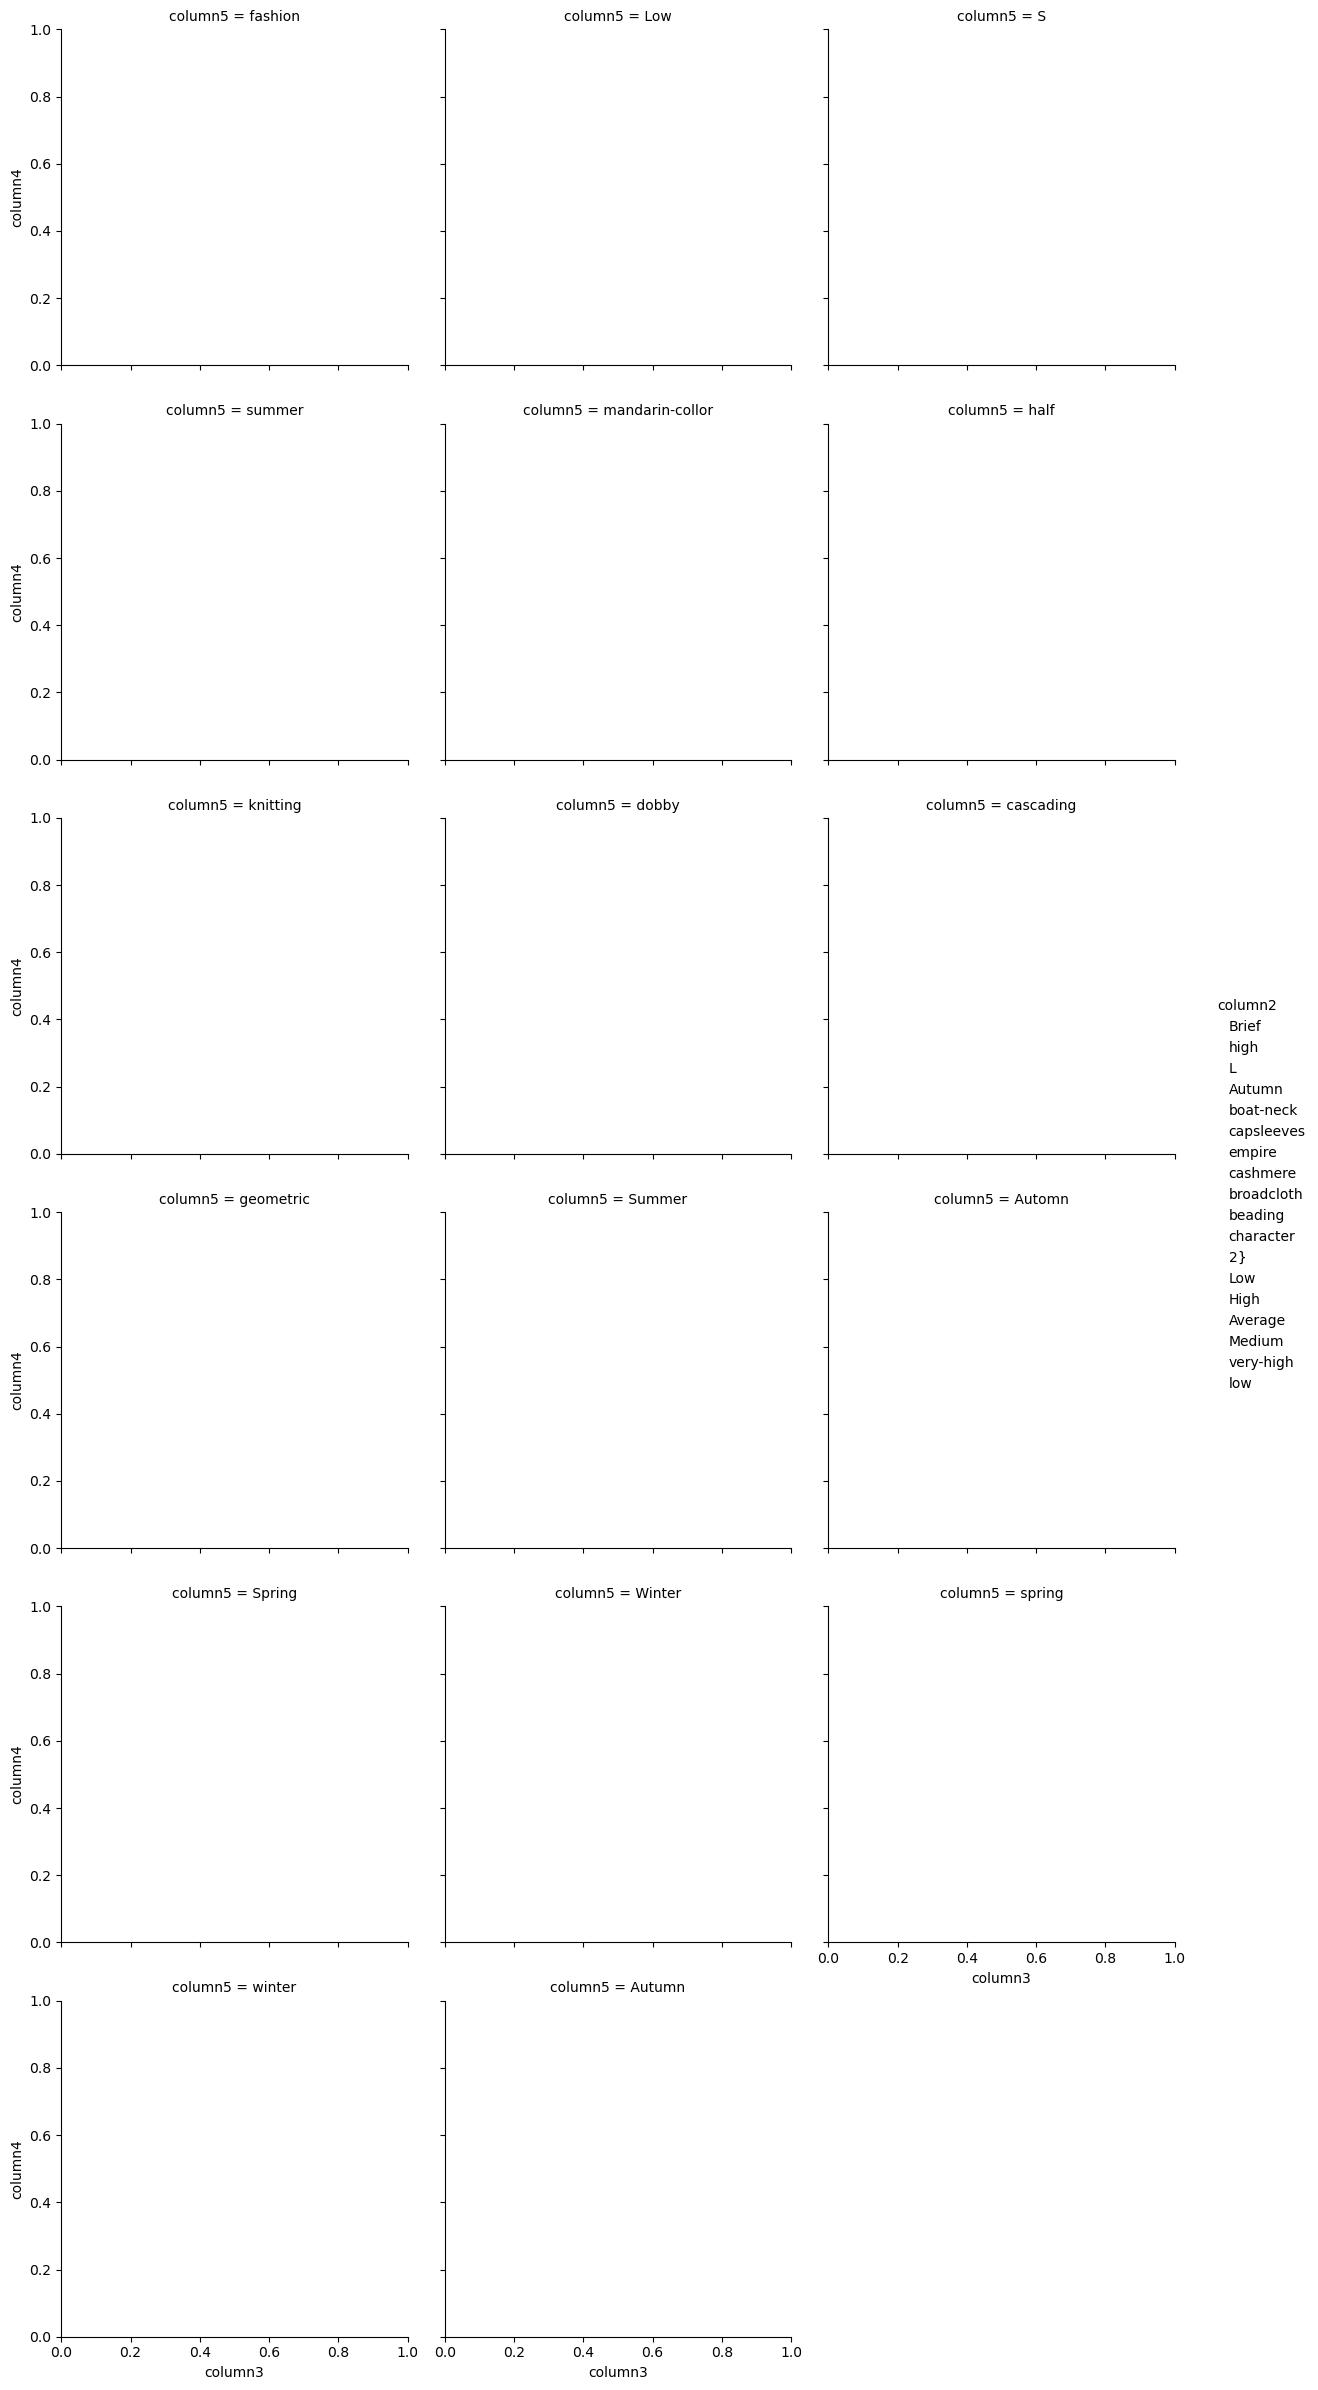

In [126]:
g = sns.FacetGrid(df, col="column5", hue="column2", col_wrap=3, height=4) 
g.map(sns.scatterplot, "column3", "column4") 
g.add_legend()

### Analysis summary

##### The phase aims to analyze a dress sales dataset to uncover insights about customer preferences, product attributes, and seasonal trends.

##### Univariate Analysis:Examined individual variables (e.g., ratings, price categories, styles) to understand their distributions.Histograms and boxplots revealed that ratings are polarized (many zeros vs. many 5s).

##### Bivariate Analysis:Explored relationships between two variables.Style vs Price: Casual dresses dominate low/average price categories, while Party/Sexy styles lean toward higher prices.Season vs Style: Summer has the highest variety, with Casual, Party, and Sexy styles most common.

##### Multivariate Analysis:Investigated three or more variables simultaneously.Material vs Decoration analysis showed cotton, polyester, and chiffon as core fabrics supporting diverse decorations, while luxury fabrics (silk, cashmere) pair with premium decorations.

##### Over all,the EDA part helped to transform the dataset into actionable insights,enabling better understanding of sales pattern.